## Model Development

### Logistic Regression

In [ ]:
#inport Library
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


In [ ]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Data/diabetes_data.csv")

# Quick check
df.head()

Mounted at /content/drive


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4,1,0,1,26,0,0,1,0,1,0,3,5,30,0,0,1,0
1,12,1,1,1,26,1,0,0,1,0,0,3,0,0,0,1,1,0
2,13,1,0,1,26,0,0,1,1,1,0,1,0,10,0,0,0,0
3,11,1,1,1,28,1,0,1,1,1,0,3,0,3,0,0,1,0
4,8,0,0,1,29,1,0,1,1,1,0,2,0,0,0,0,0,0


In [ ]:
target_cols = ["Diabetes", "HeartDiseaseorAttack", "Stroke"]

X = df.drop(columns=target_cols)
y = df[target_cols]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
y_train.shape

(49484, 3)

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

In [ ]:
multi_log_reg = MultiOutputClassifier(log_reg)
multi_log_reg.fit(X_train, y_train)


MultiOutputClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                   max_iter=1000,
                                                   solver='liblinear'))

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = multi_log_reg.predict(X_test)


In [ ]:
for i, disease in enumerate(target_cols):
    print(f"\n=== Logistic Regression Performance for {disease} ===")
    print(classification_report(y_test.iloc[:, i], y_pred_lr[:, i]))



=== Logistic Regression Performance for Diabetes ===
              precision    recall  f1-score   support

           0       0.76      0.72      0.74     10601
           1       0.74      0.77      0.75     10607

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208


=== Logistic Regression Performance for HeartDiseaseorAttack ===
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     17997
           1       0.31      0.77      0.45      3211

    accuracy                           0.71     21208
   macro avg       0.63      0.73      0.62     21208
weighted avg       0.85      0.71      0.75     21208


=== Logistic Regression Performance for Stroke ===
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     19879
           1       0.14      0.74      0.23      1329

    accura

In [ ]:
for i, disease in enumerate(target_cols):
    y_prob_lr = multi_log_reg.estimators_[i].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test.iloc[:, i], y_prob_lr)
    print(f"{disease} Logistic Regression ROC-AUC: {auc:.3f}")


Diabetes Logistic Regression ROC-AUC: 0.824
HeartDiseaseorAttack Logistic Regression ROC-AUC: 0.810
Stroke Logistic Regression ROC-AUC: 0.784


In [ ]:
#Feature importance
import pandas as pd
import numpy as np

# Coefficients for Diabetes (index 0)
coefficients = multi_log_reg.estimators_[0].coef_[0]

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

feature_importance_df.head(10)

,Feature,Coefficient,Abs_Coefficient
3,CholCheck,1.175388,1.175388
9,HvyAlcoholConsump,-0.778973,0.778973
14,HighBP,0.761057,0.761057
10,GenHlth,0.625975,0.625975
2,HighChol,0.595122,0.595122
1,Sex,0.228023,0.228023
13,DiffWalk,0.197878,0.197878
0,Age,0.159466,0.159466
8,Veggies,-0.135990,0.135990
4,BMI,0.073513,0.073513


### Random Forest Classifier

In [ ]:
#import library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Data/diabetes_data.csv")

# Quick check
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4,1,0,1,26,0,0,1,0,1,0,3,5,30,0,0,1,0
1,12,1,1,1,26,1,0,0,1,0,0,3,0,0,0,1,1,0
2,13,1,0,1,26,0,0,1,1,1,0,1,0,10,0,0,0,0
3,11,1,1,1,28,1,0,1,1,1,0,3,0,3,0,0,1,0
4,8,0,0,1,29,1,0,1,1,1,0,2,0,0,0,0,0,0


In [ ]:
#Target Variables ("Diabetes", "HeartDiseaseorAttack", "Stroke")

target_cols = ["Diabetes", "HeartDiseaseorAttack", "Stroke"]

#Feature variables
X = df.drop(columns=target_cols)
y = df[target_cols]

In [ ]:
#Train–test split 70% and 30%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
#Build the multi-label model, Random Forest + MultiOutputClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

multi_model = MultiOutputClassifier(rf)

In [ ]:
#Train the model
multi_model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       random_state=42))

In [ ]:
#Make predictions
y_pred = multi_model.predict(X_test)

In [ ]:
#Evaluate model performance
for i, disease in enumerate(target_cols):
    print(f"\n=== Performance for {disease} ===")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))


=== Performance for Diabetes ===
              precision    recall  f1-score   support

           0       0.74      0.69      0.72     10601
           1       0.71      0.76      0.73     10607

    accuracy                           0.72     21208
   macro avg       0.73      0.72      0.72     21208
weighted avg       0.73      0.72      0.72     21208


=== Performance for HeartDiseaseorAttack ===
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     17997
           1       0.37      0.18      0.24      3211

    accuracy                           0.83     21208
   macro avg       0.62      0.56      0.57     21208
weighted avg       0.79      0.83      0.80     21208


=== Performance for Stroke ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     19879
           1       0.10      0.02      0.04      1329

    accuracy                           0.92     21208
   macro avg    

In [ ]:
#ROC-AUC Score
for i, disease in enumerate(target_cols):
    y_prob = multi_model.estimators_[i].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test.iloc[:, i], y_prob)
    print(f"{disease} ROC-AUC: {auc:.3f}")

Diabetes ROC-AUC: 0.791
HeartDiseaseorAttack ROC-AUC: 0.757
Stroke ROC-AUC: 0.716


In [ ]:
#Feature importance
importances = multi_model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
4,BMI,0.232143
0,Age,0.166054
10,GenHlth,0.119230
12,PhysHlth,0.094706
14,HighBP,0.081635
11,MentHlth,0.071399
2,HighChol,0.047646
7,Fruits,0.030684
13,DiffWalk,0.030222
5,Smoker,0.029979


### XGBoost

In [ ]:
!pip install xgboost


In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


In [ ]:
target_cols = ["Diabetes", "HeartDiseaseorAttack", "Stroke"]

X = df.drop(columns=target_cols)
y = df[target_cols]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


In [ ]:
y_train.shape


(49484, 3)

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42
)


In [ ]:
multi_xgb = MultiOutputClassifier(xgb_base)
multi_xgb.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:48:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:48:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:48:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='auc',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...))

In [ ]:
y_pred_xgb = multi_xgb.predict(X_test)


In [ ]:
for i, disease in enumerate(target_cols):
    print(f"\n=== XGBoost Performance for {disease} ===")
    print(classification_report(y_test.iloc[:, i], y_pred_xgb[:, i]))



=== XGBoost Performance for Diabetes ===
              precision    recall  f1-score   support

           0       0.78      0.70      0.74     10601
           1       0.73      0.80      0.76     10607

    accuracy                           0.75     21208
   macro avg       0.76      0.75      0.75     21208
weighted avg       0.76      0.75      0.75     21208


=== XGBoost Performance for HeartDiseaseorAttack ===
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     17997
           1       0.51      0.12      0.20      3211

    accuracy                           0.85     21208
   macro avg       0.69      0.55      0.56     21208
weighted avg       0.81      0.85      0.81     21208


=== XGBoost Performance for Stroke ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     19879
           1       0.00      0.00      0.00      1329

    accuracy                           0.94   

In [ ]:
for i, disease in enumerate(target_cols):
    y_prob_xgb = multi_xgb.estimators_[i].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test.iloc[:, i], y_prob_xgb)
    print(f"{disease} XGBoost ROC-AUC: {auc:.3f}")


Diabetes XGBoost ROC-AUC: 0.829
HeartDiseaseorAttack XGBoost ROC-AUC: 0.807
Stroke XGBoost ROC-AUC: 0.773


# HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION

In [ ]:
#Import Library
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report


In [ ]:
#Define features and MULTI-DISEASE targets
target_cols = ["Diabetes", "HeartDiseaseorAttack", "Stroke"]

X = df.drop(columns=target_cols)
y = df[target_cols]


In [ ]:
#Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
y_train.shape

(49484, 3)

In [ ]:
#Logistic Regression on one representative disease (Diabetes)
y_diabetes = y_train["Diabetes"]

#Define parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [ ]:
#Run GridSearchCV
log_reg_base = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_diabetes)


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='roc_auc')

In [ ]:
best_params = grid_search.best_params_
best_params

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [ ]:
#BUILD FINAL TUNED MULTI-DISEASE LOGISTIC MODEL
best_log_reg = LogisticRegression(
    C=best_params["C"],
    penalty=best_params["penalty"],
    solver=best_params["solver"],
    class_weight="balanced",
    max_iter=1000
)

multi_log_reg = MultiOutputClassifier(best_log_reg)
multi_log_reg.fit(X_train, y_train)


MultiOutputClassifier(estimator=LogisticRegression(C=1, class_weight='balanced',
                                                   max_iter=1000, penalty='l1',
                                                   solver='liblinear'))

In [ ]:
#Model performance (after tuning)
y_pred_lr = multi_log_reg.predict(X_test)

for i, disease in enumerate(target_cols):
    print(f"\n=== Tuned Logistic Regression Performance for {disease} ===")
    print(classification_report(y_test.iloc[:, i], y_pred_lr[:, i]))



=== Tuned Logistic Regression Performance for Diabetes ===
              precision    recall  f1-score   support

           0       0.76      0.72      0.74     10601
           1       0.74      0.77      0.75     10607

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208


=== Tuned Logistic Regression Performance for HeartDiseaseorAttack ===
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     17997
           1       0.31      0.77      0.45      3211

    accuracy                           0.71     21208
   macro avg       0.63      0.73      0.63     21208
weighted avg       0.85      0.71      0.75     21208


=== Tuned Logistic Regression Performance for Stroke ===
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     19879
           1       0.14      0.74      0.23    

In [ ]:
#ROC-AUC after tuning
for i, disease in enumerate(target_cols):
    y_prob_lr = multi_log_reg.estimators_[i].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test.iloc[:, i], y_prob_lr)
    print(f"{disease} Tuned Logistic Regression ROC-AUC: {auc:.3f}")


Diabetes Tuned Logistic Regression ROC-AUC: 0.824
HeartDiseaseorAttack Tuned Logistic Regression ROC-AUC: 0.810
Stroke Tuned Logistic Regression ROC-AUC: 0.784


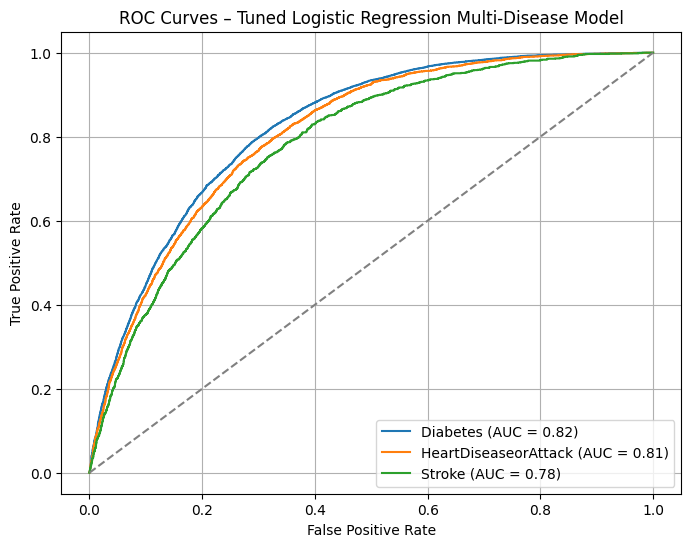

In [ ]:
#ROC CURVE – TUNED LOGISTIC REGRESSION
#Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

#Import required libraries
target_cols = ["Diabetes", "HeartDiseaseorAttack", "Stroke"]

#Plot ROC curves
plt.figure(figsize=(8, 6))

for i, disease in enumerate(target_cols):
    # Get predicted probabilities
    y_prob = multi_log_reg.estimators_[i].predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob)

    # Compute AUC
    auc = roc_auc_score(y_test.iloc[:, i], y_prob)

    # Plot
    plt.plot(fpr, tpr, label=f"{disease} (AUC = {auc:.2f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Tuned Logistic Regression Multi-Disease Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



In [ ]:
# Risk level function
def risk_level(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

# Select one sample individual
sample = X_test.iloc[[0]]

# Get probabilities for all diseases
probabilities = {}

for i, disease in enumerate(target_cols):
    probabilities[disease] = round(
        multi_model.estimators_[i].predict_proba(sample)[:, 1][0], 2
    )

# Final output table (ALL diseases)
final_output = pd.DataFrame({
    "Disease": ["Diabetes", "Heart Disease", "Stroke"],
    "Probability": [
        probabilities["Diabetes"],

        probabilities["HeartDiseaseorAttack"],
        probabilities["Stroke"]
    ],
    "Risk_Level": [
        risk_level(probabilities["Diabetes"]),

        risk_level(probabilities["HeartDiseaseorAttack"]),
        risk_level(probabilities["Stroke"])
    ]
})

final_output


,Disease,Probability,Risk_Level
0,Diabetes,0.85,High Risk
1,Heart Disease,0.08,Low Risk
2,Stroke,0.04,Low Risk


In [ ]:
#Threshold Simulation for Disease
from sklearn.metrics import recall_score, precision_score

thresholds = [0.3, 0.5, 0.7]

for i, disease in enumerate(target_cols):
    print(f"\nThreshold Simulation for {disease}")

    y_true = y_test.iloc[:, i]
    y_prob = multi_log_reg.estimators_[i].predict_proba(X_test)[:, 1]

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)

        print(f"Threshold {t}: Recall = {recall:.2f}, Precision = {precision:.2f}")




Threshold Simulation for Diabetes
Threshold 0.3: Recall = 0.93, Precision = 0.66
Threshold 0.5: Recall = 0.77, Precision = 0.74
Threshold 0.7: Recall = 0.51, Precision = 0.81

Threshold Simulation for HeartDiseaseorAttack
Threshold 0.3: Recall = 0.94, Precision = 0.24
Threshold 0.5: Recall = 0.77, Precision = 0.31
Threshold 0.7: Recall = 0.47, Precision = 0.42

Threshold Simulation for Stroke
Threshold 0.3: Recall = 0.92, Precision = 0.10
Threshold 0.5: Recall = 0.74, Precision = 0.14
Threshold 0.7: Recall = 0.44, Precision = 0.19


# 5-Fold Cross-Validation in Python

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, disease in enumerate(target_cols):
    auc_scores = []

    for train_index, val_index in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_cv, y_train_cv.iloc[:, i])

        y_prob = model.predict_proba(X_val_cv)[:, 1]
        auc = roc_auc_score(y_val_cv.iloc[:, i], y_prob)
        auc_scores.append(auc)

    print(f"{disease} Mean ROC-AUC: {np.mean(auc_scores):.3f}")


Diabetes Mean ROC-AUC: 0.823
HeartDiseaseorAttack Mean ROC-AUC: 0.808
Stroke Mean ROC-AUC: 0.784
